In [1]:
import torch
import torch.nn as nn

device = "cuda"

torch.manual_seed(42)

In [2]:
from pathlib import Path
from torchvision import datasets, transforms

DATA_DIR = Path("datasets")

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(root=DATA_DIR, train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root=DATA_DIR, train=False, download=True, transform=transform)

print(len(train_dataset), len(test_dataset))

60000 10000


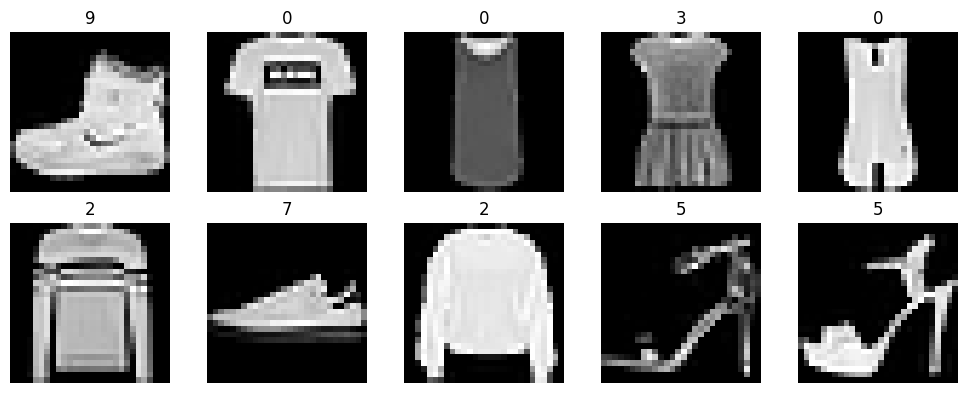

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from torch.utils.data import DataLoader

codings_dim = 32
generator = nn.Sequential(
    nn.Linear(codings_dim, 128), nn.ReLU(),
    nn.Linear(128, 256), nn.ReLU(),
    nn.Linear(256, 1*28*28), nn.Sigmoid(),
    nn.Unflatten(dim=1, unflattened_size=(1,28,28))
).to(device)

discriminator = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1*28*28, 256), nn.ReLU(),
    nn.Linear(256, 128), nn.ReLU(),
    nn.Linear(128, 1), nn.Sigmoid()
).to(device)

def train_gen(generator:nn.Module, discriminator:nn.Module, train_loader:DataLoader, codings_dim, n_epochs:int=20):
    